# Regression assignment
### Dataset: Medical Cost Personal Dataset
link download: https://www.kaggle.com/datasets/mirichoi0218/insurance

### Assignment: accurate prediction of insurance costs

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [114]:
# read csv-file
dataset = pd.read_csv('insurance.csv')
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Columns:

age: age of primary beneficiary

sex: insurance contractor gender, female, male

bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

children: Number of children covered by health insurance / Number of dependents

smoker: Smoking

region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

charges: Individual medical costs billed by health insurance


In [115]:
#df.columns = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

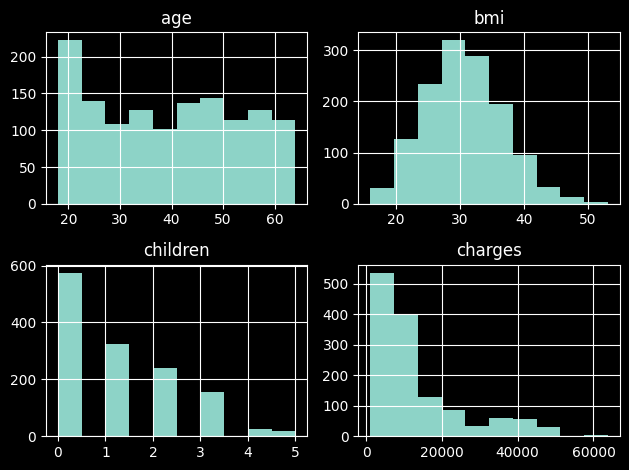

In [116]:
hist = dataset.hist() # hist = dataset.hist(figsize=(15, 10)) # to set figure size
plt.tight_layout()
plt.show()

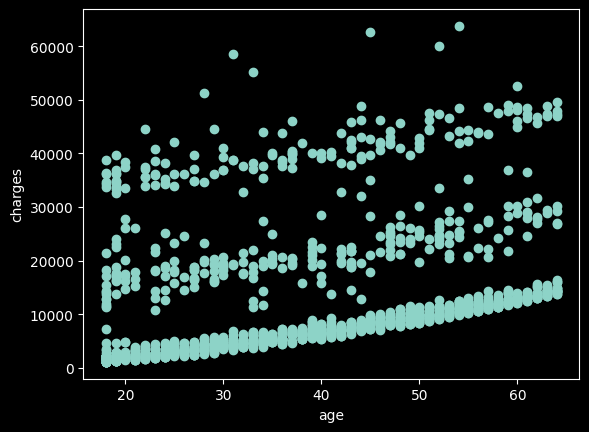

In [117]:
plt.scatter(dataset['age'], dataset['charges'])
plt.xlabel('age')
plt.ylabel('charges')
plt.show()

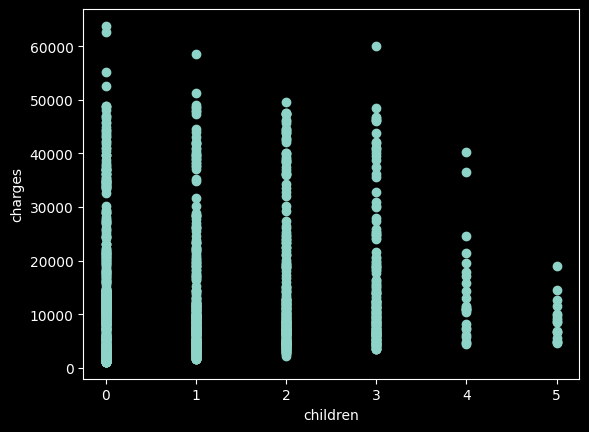

In [118]:
plt.scatter(dataset['children'], dataset['charges'])
plt.xlabel('children')
plt.ylabel('charges')
plt.show()

In [119]:
from sklearn.pipeline import Pipeline

#numerical columns
# convert to numeric
numeric_cols = ['age', 'bmi', 'children', 'charges']
for col in numeric_cols:
    dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

#dataset = dataset.drop(columns = ['charges'])

# not numerical columns
categorical_cols = ['sex', 'smoker', 'region']
dataset = dataset[categorical_cols + numeric_cols]
#y = dataset['charges'].values.reshape(-1, 1)



In [120]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Normalize datas with StandardScaler from sklearn.preprocessing

In [121]:
arr = dataset

In [122]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, categorical_cols),
    ('num', num_pipeline, numeric_cols)
])
dataset = preprocessor.fit_transform(dataset)


In [123]:
dataset

array([[ 1.        ,  0.        ,  0.        , ..., -0.45332   ,
        -0.90861367,  0.2985838 ],
       [ 0.        ,  1.        ,  1.        , ...,  0.5096211 ,
        -0.07876719, -0.95368917],
       [ 0.        ,  1.        ,  1.        , ...,  0.38330685,
         1.58092576, -0.72867467],
       ...,
       [ 1.        ,  0.        ,  1.        , ...,  1.0148781 ,
        -0.90861367, -0.96159623],
       [ 1.        ,  0.        ,  1.        , ..., -0.79781341,
        -0.90861367, -0.93036151],
       [ 1.        ,  0.        ,  0.        , ..., -0.26138796,
        -0.90861367,  1.31105347]], shape=(1338, 12))

In [124]:
# segregate x, y from dataset with x is all columns except the last one: 'charges'-column, y is the 'charges' column
x = dataset[:, :-1]
y = dataset[:, -1]

In [125]:
# split dataset in 80/20
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [126]:
#check shape of datas
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 11)
(268, 11)
(1070,)
(268,)


==================================
### OLS
##### Apply formula W = ((A.T * A)^-1) * A.T * y

In [127]:
#create one array[n][1] with ones and attach with x_train data
#before x_train.shape = [1070, 10] -> after new x_train.shape = [1070, 11] because of one column with ones
ones = np.ones((x_train.shape[0], 1))
x_train_bar = np.concatenate((ones, x_train), axis=1)
print(x_train_bar.shape)

(1070, 12)


In [128]:
# apply OLS-formula
a = np.matmul(x_train_bar.T, x_train_bar)
b = np.matmul(x_train_bar.T, y_train)
c = np.linalg.inv(a)
w = np.matmul(c, b)
w

array([ 0.5       ,  1.        ,  0.75      ,  0.        ,  2.        ,
       -1.        , -2.        , -2.        , -1.        ,  0.29814163,
        0.16974826,  0.04233444])

In [129]:
from sklearn.metrics import r2_score
ones = np.ones((x_test.shape[0], 1))
x_test_bar = np.concatenate((ones, x_test), axis=1)
y_predict = np.matmul(w, x_test_bar.T)
print('R2-Score:', r2_score(y_test, y_predict))

R2-Score: 0.5081683856186359


Use library sklearn with defined class

In [130]:
#
from sklearn import linear_model

ols = linear_model.LinearRegression()
ols.fit(x_train, y_train)
print(ols.coef_)
print(ols.intercept_)

[ 7.67903627e-04 -7.67903627e-04 -9.76876552e-01  9.76876552e-01
  3.79650419e-02  7.34443256e-03 -1.63792738e-02 -2.89302007e-02
  2.98141630e-01  1.69748264e-01  4.23344352e-02]
0.5809220422984166


In [131]:
y_predict = ols.predict(x_test)
print('R2-Score:', r2_score(y_test, y_predict))

R2-Score: 0.7835929767120722


===============================
### RIDGE
##### Apply formula w = ((A.T * A + lambda)^-1) * A.T * y

In [132]:
ones = np.ones((x_train.shape[0], 1))
x_train_bar = np.concatenate((ones, x_train), axis=1)
# create an identity matrix with ones on the main diagonal, dimension of identity matrix is the number of x_train columns
i = np.identity(x_train.shape[1]+1)

In [133]:
# apply Ridge-formula
lambda_r = 0.2
#np.matmul: traditional matrix multiplication (the dot product of rows and columns)
#np.multiply: element-wise multiplication (multiplying corresponding cells together)
a = np.matmul(x_train_bar.T, x_train_bar) + np.multiply(lambda_r, i)
b = np.matmul(x_train_bar.T, y_train)
c = np.linalg.inv(a)
w = np.matmul(c, b)
w

array([ 0.25800471,  0.12973319,  0.12827152, -0.8472612 ,  1.10526591,
        0.10243602,  0.07180499,  0.04819454,  0.03556916,  0.29806584,
        0.16970996,  0.0423391 ])

In [134]:
ones = np.ones((x_test.shape[0], 1))
x_test_bar = np.concatenate((ones, x_test), axis=1)
y_predict = np.matmul(w, x_test_bar.T)
print('R2-Score:', r2_score(y_test, y_predict))

R2-Score: 0.7835629101404306


Use library sklearn with defined class

In [135]:
ridge = linear_model.Ridge()
ridge.fit(x_train, y_train)
print(ridge.coef_)
print(ridge.intercept_)

[ 6.01928645e-04 -6.01928645e-04 -9.74039027e-01  9.74039027e-01
  3.78133547e-02  7.16457989e-03 -1.60509547e-02 -2.89269799e-02
  2.97768570e-01  1.69566121e-01  4.23520700e-02]
0.5792412897150262


In [136]:
y_predict = ridge.predict(x_test)
print('R2-Score:', r2_score(y_test, y_predict))

R2-Score: 0.7834425664293833


Plot lambda and coef

Text(0, 0.5, 'coefficients')

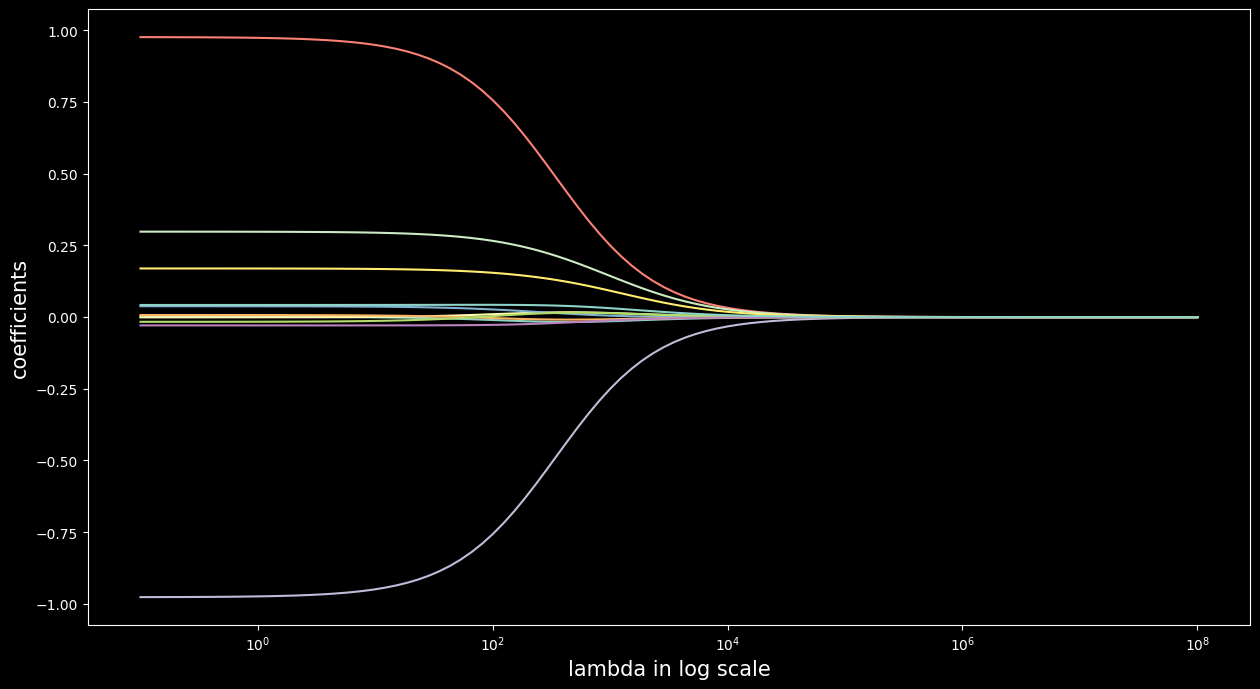

In [142]:
coef = []
n_alphas = 100
alphas = np.logspace(-1, 8, n_alphas)
for alpha in alphas:
    ridge = linear_model.Ridge(alpha=alpha)
    ridge.fit(x_train, y_train)
    coef.append(ridge.coef_)

figure, ax = plt.subplots(figsize=(15, 8))
ax.plot(alphas, coef)
ax.set_xscale('log')
ax.set_xlabel('lambda in log scale', fontsize=15)
ax.set_ylabel('coefficients', fontsize=15)

===============================
### LASSO

In [138]:
lasso = linear_model.Lasso(alpha=0.6)
lasso.fit(x_train, y_train)
print(lasso.coef_)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [139]:
y_pred = lasso.predict(x_test)
print('R2-Score:', r2_score(y_test, y_pred))

R2-Score: -0.0009192486886582252


Text(0, 0.5, 'coefficients')

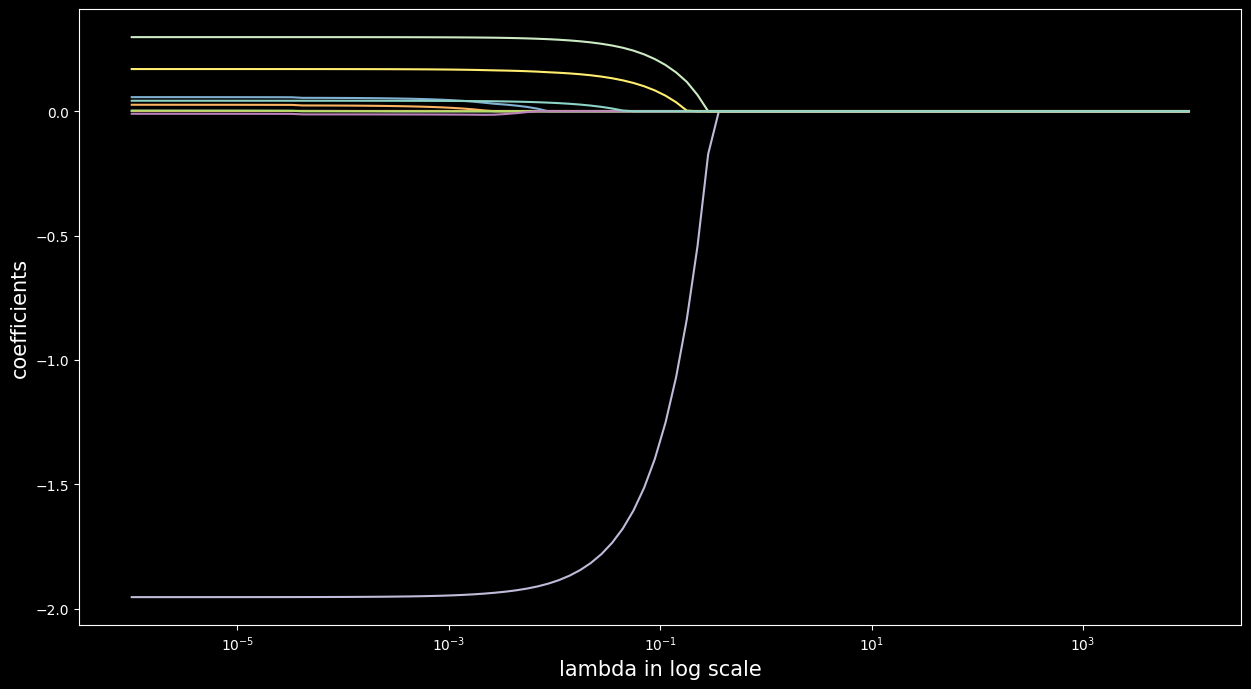

In [140]:
coef = []
n_alphas = 100
alphas = np.logspace(-6, 4, n_alphas)
for alpha in alphas:
    lasso = linear_model.Lasso(alpha=alpha)
    lasso.fit(x_train, y_train)
    coef.append(lasso.coef_)

figure, ax = plt.subplots(figsize=(15, 8))
ax.plot(alphas, coef)
ax.set_xscale('log')
ax.set_xlabel('lambda in log scale', fontsize=15)
ax.set_ylabel('coefficients', fontsize=15)

In [141]:
arr

,sex,smoker,region,age,bmi,children,charges
0,female,yes,southwest,19,27.900,0,16884.92400
1,male,no,southeast,18,33.770,1,1725.55230
2,male,no,southeast,28,33.000,3,4449.46200
3,male,no,northwest,33,22.705,0,21984.47061
4,male,no,northwest,32,28.880,0,3866.85520
...,...,...,...,...,...,...,...
1333,male,no,northwest,50,30.970,3,10600.54830
1334,female,no,northeast,18,31.920,0,2205.98080
1335,female,no,southeast,18,36.850,0,1629.83350
1336,female,no,southwest,21,25.800,0,2007.94500


=========================================
### K-Fold

In [145]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits=5)
i = 0
model = linear_model.LinearRegression()
x = dataset[:, :-1]
y = dataset[:, -1]

for train_index, test_index in kfold.split(x):
    x_train = x[train_index]
    x_test = x[test_index]
    y_train = y[train_index]
    y_test = y[test_index]
    model.fit(x_train, y_train)
    print(f'N_{i} R2_score {r2_score(y_test,model.predict(x_test))}')
    i += 1

N_0 R2_score 0.761481793256997
N_1 R2_score 0.7064933920916752
N_2 R2_score 0.7780634309738972
N_3 R2_score 0.7326947536329198
N_4 R2_score 0.7555747517813813


====================================
### Polynomial Regression

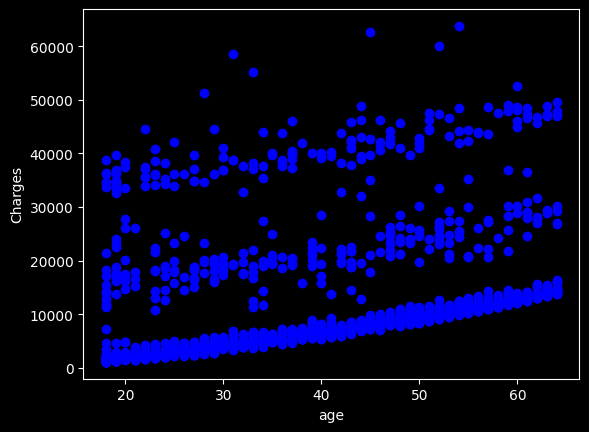

In [148]:
plt.scatter(arr.age, arr.charges, color='blue')
plt.xlabel('age')
plt.ylabel('Charges')
plt.show()

In [149]:
x = np.array(arr['age'])
y = np.array(arr['charges'])
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [151]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 1)
(268, 1)
(1070, 1)
(268, 1)


In [152]:
from sklearn.preprocessing import PolynomialFeatures
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_train_poly

array([[1.000e+00, 4.600e+01, 2.116e+03],
       [1.000e+00, 4.700e+01, 2.209e+03],
       [1.000e+00, 5.200e+01, 2.704e+03],
       ...,
       [1.000e+00, 5.800e+01, 3.364e+03],
       [1.000e+00, 3.700e+01, 1.369e+03],
       [1.000e+00, 5.500e+01, 3.025e+03]], shape=(1070, 3))

In [153]:
model = linear_model.LinearRegression()
#fit the training data to model
model.fit(x_train_poly, y_train)

print(f'Coefficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')

Coefficients: [[  0.         -43.49828901   3.59171863]]
Intercept: [8783.80322787]


In [154]:
x_test_poly = poly.transform(x_test)
y_predict = model.predict(x_test_poly)
print('R2-Score:', r2_score(y_test, y_predict))

R2-Score: 0.11873673494547743


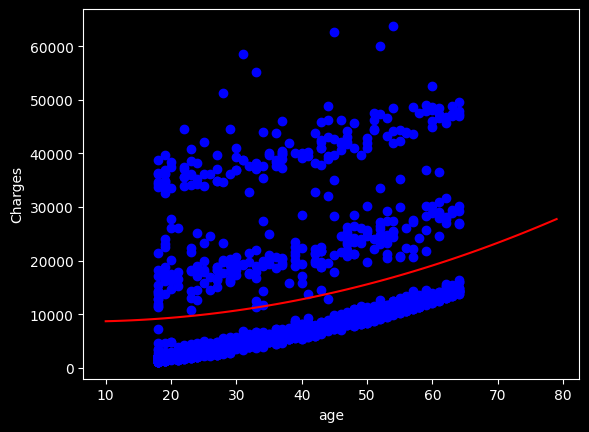

In [156]:
plt.scatter(arr.age, arr.charges, color='blue')
plt.xlabel('age')
plt.ylabel('Charges')
xx = np.arange(10, 80, 1)
yy = yy = model.intercept_[0] + model.coef_[0][1]*xx + model.coef_[0][2]*(xx**2)
plt.plot(xx, yy, color='red')
plt.show()